# Illustration Exercise — Training and Fine-Tuning

## Context

Hoffmann et al. (2022) showed that for a given compute budget $C$ (FLOPs), the
loss-minimising allocation follows the power laws
$N^* = 0.1192 \cdot C^{0.4937}$ (parameters) and
$D^* = 2.1714 \cdot C^{0.4977}$ (training tokens).
This means parameters and data should scale in roughly equal proportion.
Models above the frontier are over-parameterised for their compute; models below
are under-trained. This exercise plots the compute-optimal frontier and overlays
six well-known model families to show which were over- or under-trained.

## Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pathlib

plt.style.use(["science", "no-latex"])

# Chinchilla coefficients (Hoffmann et al. 2022, Table A3)
compute = np.logspace(20, 26, 400)      # FLOPs
N_opt   = 0.1192 * compute ** 0.4937   # optimal parameters
D_opt   = 2.1714 * compute ** 0.4977   # optimal tokens

# Public model checkpoints: (parameters, training tokens)
models = {
    "GPT-3":      (175e9,  300e9),
    "PaLM":       (540e9,  780e9),
    "Gopher":     (280e9,  300e9),
    "Chinchilla": ( 70e9,  1.4e12),
    "LLaMA-7B":   (  7e9,  1.0e12),
    "LLaMA-65B":  ( 65e9,  1.4e12),
}
colors = ["#e41a1c", "#377eb8", "#ff7f00", "#4daf4a", "#984ea3", "#a65628"]

print("Model datapoints loaded.")

Model datapoints loaded.


## Figure

Saved to C:\Users\jfimb\Documents\book-course-template\book\chapters\03-llm-training-finetuning\figures\fig_illustration.pdf


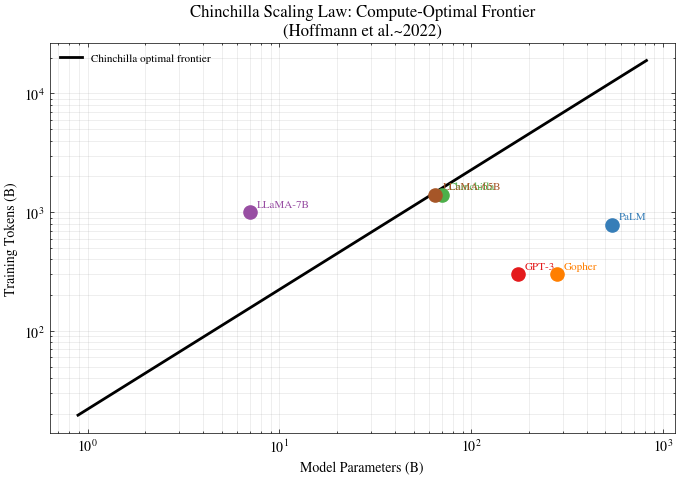

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(N_opt / 1e9, D_opt / 1e9,
          "k-", lw=2, label="Chinchilla optimal frontier")

for (name, (n, d)), c in zip(models.items(), colors):
    ax.scatter(n / 1e9, d / 1e9, color=c, s=90, zorder=5)
    ax.annotate(name, xy=(n / 1e9, d / 1e9),
                xytext=(5, 4), textcoords="offset points",
                fontsize=8, color=c)

ax.set_xlabel("Model Parameters (B)")
ax.set_ylabel("Training Tokens (B)")
ax.set_title("Chinchilla Scaling Law: Compute-Optimal Frontier\n"
             "(Hoffmann et al.~2022)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

out_path = pathlib.Path(
    "../../../book/chapters/03-llm-training-finetuning/figures/fig_illustration.pdf"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved to {out_path.resolve()}")
plt.show()

## Your Turn

Using the Chinchilla coefficients above, compute the compute-optimal parameter
count for a training budget of $10^{23}$ FLOPs and $10^{25}$ FLOPs.
Then look up the reported parameters and training tokens for GPT-4 (estimated)
or another model of your choice and add it to the plot. Is the model above or
below the frontier? What does that imply about its training efficiency?

# Chapter 3 — Exercises: Training and Fine-Tuning Large Language Models

This notebook contains starter code for the exercises in Chapter 3 of *Large Language Models in Finance*.

**Exercises:**
- [B] Chinchilla scaling law calculator
- [I] LoRA fine-tuning on Financial PhraseBank
- [A] Hallucination evaluation under distribution shift

[Placeholder — fill in with exercise starter code when drafting the chapter]